In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.optimize import differential_evolution

# --- Physical constants and basin parameters ---
G = 6.67430e-11  # m^3/kg/s^2
G_mGal = G * 1e5  # convert to mGal

Lx, Ly = 2000, 2000      # extent of model (m)
true_h0 = 500            # true max basin depth (m)
true_sigma = 600         # true Gaussian spread (m)
true_density_contrast = -300  # true sediment contrast (kg/m³)

# --- Grid definitions ---
nx, ny, nz = 40, 40, 10
x_edges = np.linspace(-Lx/2, Lx/2, nx+1)
y_edges = np.linspace(-Ly/2, Ly/2, ny+1)
z_edges = np.linspace(-true_h0, 0, nz+1)
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
zc = 0.5 * (z_edges[:-1] + z_edges[1:])
Xc, Yc, Zc = np.meshgrid(xc, yc, zc, indexing='ij')

# True basin surface
true_surface = -true_h0 * np.exp(-(Xc[:, :, 0]**2 + Yc[:, :, 0]**2) / (2 * true_sigma**2))

# True density model
rho_true = np.zeros((nx, ny, nz))
for iz in range(nz):
    z_top = z_edges[iz + 1]
    rho_true[:, :, iz] = true_density_contrast * (z_top < true_surface)

# Observation grid
x_obs = np.linspace(-Lx/2, Lx/2, 50)
y_obs = np.linspace(-Ly/2, Ly/2, 50)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs)

# --- Gravity forward modeling functions ---
@njit
def prism_gz(xo, yo, zo, x1, x2, y1, y2, z1, z2, drho):
    gz = 0.0
    for i in [x1, x2]:
        for j in [y1, y2]:
            for k in [z1, z2]:
                dx = i - xo
                dy = j - yo
                dz = k - zo
                R = np.sqrt(dx**2 + dy**2 + dz**2 + 1e-10)
                sign = (-1)**((i == x2) + (j == y2) + (k == z2))
                gz += sign * np.arctan2(dx * dy, dz * R + 1e-10)
    return G_mGal * drho * gz

@njit(parallel=True)
def compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_model):
    nx, ny, nz = rho_model.shape
    nobs_x, nobs_y = Xobs.shape
    gz_obs = np.zeros((nobs_x, nobs_y))

    for i in prange(nobs_x):
        for j in range(nobs_y):
            xo, yo, zo = Xobs[i, j], Yobs[i, j], Zobs[i, j]
            gz = 0.0
            for ix in range(nx):
                for iy in range(ny):
                    for iz in range(nz):
                        drho = rho_model[ix, iy, iz]
                        if drho == 0:
                            continue
                        x1, x2 = x_edges[ix], x_edges[ix + 1]
                        y1, y2 = y_edges[iy], y_edges[iy + 1]
                        z1, z2 = z_edges[iz], z_edges[iz + 1]
                        gz += prism_gz(xo, yo, zo, x1, x2, y1, y2, z1, z2, drho)
            gz_obs[i, j] = gz
    return gz_obs

# --- Generate true gravity anomaly ---
gz_true = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_true)

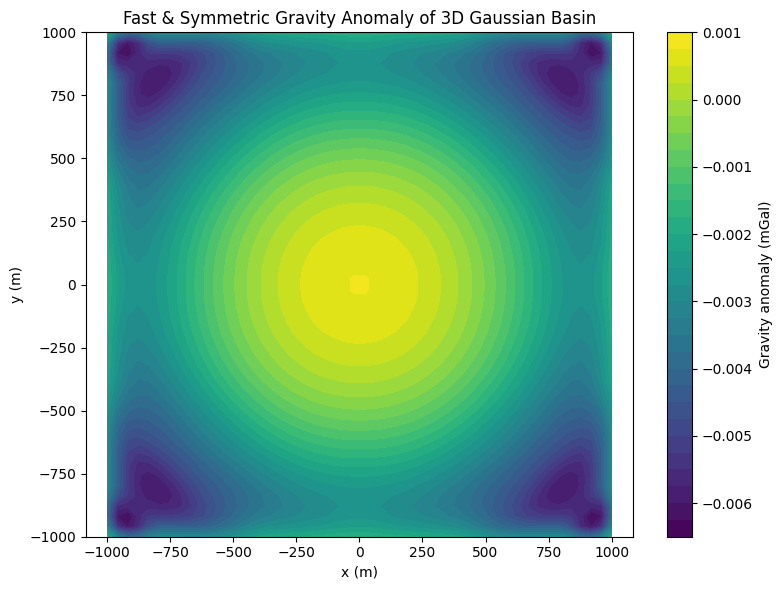

In [3]:
plt.figure(figsize=(8, 6))
cp = plt.contourf(Xobs, Yobs, gz_true, levels=30, cmap='viridis')
plt.colorbar(cp, label='Gravity anomaly (mGal)')
plt.title('Fast & Symmetric Gravity Anomaly of 3D Gaussian Basin')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()

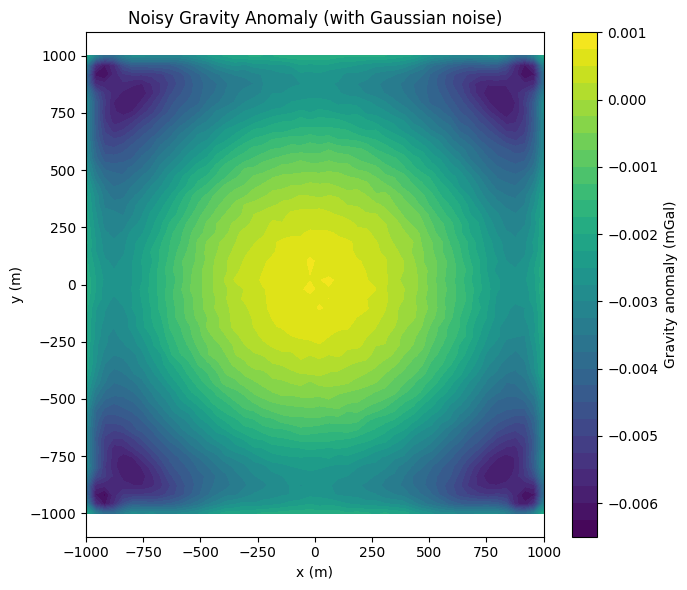

In [4]:
# --- Add Gaussian noise ---
noise_std = 0.00004  # mGal
#np.random.seed(42)
gz_noisy = gz_true + np.random.normal(0, noise_std, gz_true.shape)

plt.figure(figsize=(7,6))
cp = plt.contourf(Xobs, Yobs, gz_noisy, levels=30, cmap='viridis')
plt.colorbar(cp, label='Gravity anomaly (mGal)')
plt.title('Noisy Gravity Anomaly (with Gaussian noise)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
# --- Inversion Objective Function with fixed drho ---
fixed_drho = true_density_contrast  # fixed known value

iteration_log = []
param_log = []

def objective(params):
    h0_try, sigma_try = params
    surface_try = -h0_try * np.exp(-(Xc[:, :, 0]**2 + Yc[:, :, 0]**2) / (2 * sigma_try**2))
    
    rho_try = np.zeros((nx, ny, nz))
    for iz in range(nz):
        z_top = z_edges[iz + 1]
        rho_try[:, :, iz] = fixed_drho * (z_top < surface_try)

    gz_model = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_try)
    return np.sqrt(np.mean((gz_model.ravel() - gz_noisy.ravel())**2))

def plot_current_model(params, iter_num):
    h0_try, sigma_try = params
    surface_try = -h0_try * np.exp(-(Xc[:, :, 0]**2 + Yc[:, :, 0]**2) / (2 * sigma_try**2))

    rho_try = np.zeros((nx, ny, nz))
    for iz in range(nz):
        z_top = z_edges[iz + 1]
        rho_try[:, :, iz] = fixed_drho * (z_top < surface_try)

    gz_try = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_try)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    cf1 = axs[0].contourf(Xobs, Yobs, gz_try, levels=30, cmap='viridis')
    axs[0].set_title(f"Gravity @ Iter {iter_num}")
    plt.colorbar(cf1, ax=axs[0])
    axs[0].axis('equal')
    axs[0].set_xlabel("x (m)")
    axs[0].set_ylabel("y (m)")
    
    cf2 = axs[1].contourf(Xc[:, :, 0], Yc[:, :, 0], surface_try, levels=30, cmap='terrain')
    axs[1].set_title(f"Basin Surface @ Iter {iter_num}")
    plt.colorbar(cf2, ax=axs[1])
    axs[1].axis('equal')
    axs[1].set_xlabel("x (m)")
    axs[1].set_ylabel("y (m)")
    
    plt.suptitle(f"Iteration {iter_num} Model Snapshot")
    plt.tight_layout()
    plt.show()

def track_progress(xk, convergence):
    rmse = objective(xk)
    iteration_log.append(rmse)
    param_log.append(xk.copy())

    print(f"Iteration {len(iteration_log)}: RMSE = {rmse:.4f}, h0 = {xk[0]:.2f}, sigma = {xk[1]:.2f}")
    
    if len(iteration_log) % 5 == 0:
        plot_current_model(xk, len(iteration_log))

bounds = [(100, 1000), (100, 1200)]  # Only h0 and sigma bounds

print("Running Differential Evolution inversion (fixed density contrast)...")
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=60,
    popsize=15,
    tol=1e-5,
    seed=42,
    workers=-1,
    callback=track_progress
)

best_h0, best_sigma = result.x
print(f"\nEstimated Parameters:")
print(f"  h0     = {best_h0:.2f} m")
print(f"  sigma  = {best_sigma:.2f} m")
print(f"  drho   = {fixed_drho:.2f} kg/m³ (fixed)")

best_surface = -best_h0 * np.exp(-(Xc[:, :, 0]**2 + Yc[:, :, 0]**2) / (2 * best_sigma**2))
rho_best = np.zeros((nx, ny, nz))
for iz in range(nz):
    z_top = z_edges[iz + 1]
    rho_best[:, :, iz] = fixed_drho * (z_top < best_surface)

gz_best = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_best)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

cf1 = axs[0].contourf(Xobs, Yobs, gz_noisy, levels=30, cmap='viridis')
axs[0].set_title("Noisy Observed Gravity (mGal)")
plt.colorbar(cf1, ax=axs[0])
axs[0].set_xlabel("x (m)")
axs[0].set_ylabel("y (m)")
axs[0].axis('equal')

cf2 = axs[1].contourf(Xobs, Yobs, gz_best, levels=30, cmap='viridis')
axs[1].set_title("Best-fit Gravity (mGal)")
plt.colorbar(cf2, ax=axs[1])
axs[1].set_xlabel("x (m)")
axs[1].set_ylabel("y (m)")
axs[1].axis('equal')

cf3 = axs[2].contourf(Xc[:, :, 0], Yc[:, :, 0], best_surface, levels=30, cmap='terrain')
axs[2].set_title("Inverted Basin Surface (m)")
plt.colorbar(cf3, ax=axs[2])
axs[2].set_xlabel("x (m)")
axs[2].set_ylabel("y (m)")
axs[2].axis('equal')

plt.tight_layout()
plt.show()

# --- Plot Convergence Curve ---
plt.figure(figsize=(8, 4))
plt.plot(iteration_log, marker='o')
plt.title("Convergence of RMSE over Iterations")
plt.xlabel("Iteration")
plt.ylabel("RMSE (mGal)")
plt.grid(True)
plt.tight_layout()
plt.show()


Running Differential Evolution inversion (fixed density contrast)...


C:\Users\monda\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
